# Mirror reflection via a reflection matrix

Reflect an incident ray `u` off a mirror with normal `v` using the **reflection
matrix**

```
M(v) = I - 2 v vᵀ / (v·v)
```

so that `w = M(v) u`. Then compare the two ways of tilting the mirror:

- rotating the mirror normal **about the Z axis**, and looking at how much the
  reflected ray's angle changes **in Y**
- rotating the mirror normal **about the Y axis**, and looking at how much the
  reflected ray's angle changes **in Z**

i.e. for each rotation axis, we track the angle in the *other* transverse axis
- the one a beam profiler downstream would actually see move.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


def reflection_matrix(v):
    """3x3 matrix that reflects a vector across the plane with normal v."""
    v = np.asarray(v, dtype=float)
    return np.eye(3) - 2 * np.outer(v, v) / np.dot(v, v)


def Ry(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


def Rz(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


In [2]:
# sanity check: M(v) must be orthogonal (it's a reflection) and must preserve
# vector length -- if either fails, something is wrong with the construction.
rng = np.random.default_rng(0)
for _ in range(5):
    v = rng.normal(size=3)
    u = rng.normal(size=3)
    M = reflection_matrix(v)
    w = M @ u
    print(f"orthogonal (M Mᵀ = I)? {np.allclose(M @ M.T, np.eye(3))}   "
          f"|u| = {np.linalg.norm(u):.4f}  |w| = {np.linalg.norm(w):.4f}")

orthogonal (M Mᵀ = I)? True   |u| = 0.6547  |w| = 0.6547
orthogonal (M Mᵀ = I)? True   |u| = 1.4112  |w| = 1.4112
orthogonal (M Mᵀ = I)? True   |u| = 0.9656  |w| = 0.9656
orthogonal (M Mᵀ = I)? True   |u| = 1.5599  |w| = 1.5599
orthogonal (M Mᵀ = I)? True   |u| = 1.0524  |w| = 1.0524


## Setup

Mirror normal starts along `x`. Incident ray lies in the xy-plane, hitting the
mirror at angle `theta_i` from the normal.

In [12]:
v0 = np.array([1.0, 0.0, 0.0])  # mirror normal, untilted

theta_i = np.deg2rad(45)
u = np.array([-np.cos(theta_i), np.sin(theta_i), 0.0])  # incident ray, in the xy-plane

w0 = reflection_matrix(v0) @ u  # baseline reflected ray, mirror untilted
print("incident ray u  =", np.round(u, 4))
print("baseline reflected ray w0 =", np.round(w0, 4))

incident ray u  = [-0.7071  0.7071  0.    ]
baseline reflected ray w0 = [0.7071 0.7071 0.    ]


In [4]:
angles_deg = np.linspace(-20, 20, 81)
angles = np.deg2rad(angles_deg)

# Rotate mirror normal about Z, track the reflected ray's angle in Y
y_angle_deg = []
for a in angles:
    v = Rz(a) @ v0
    w = reflection_matrix(v) @ u
    y_angle_deg.append(w[1])
y_angle_deg = np.array(y_angle_deg)
# y_deflection = y_angle_deg - y_angle_deg[len(angles) // 2]  # relative to a=0

# Rotate mirror normal about Y, track the reflected ray's angle in Z
z_angle_deg = []
for a in angles:
    v = Ry(a) @ v0
    w = reflection_matrix(v) @ u
    z_angle_deg.append(w[2])
z_angle_deg = np.array(z_angle_deg)
# z_deflection = z_angle_deg - z_angle_deg[len(angles) // 2]  # relative to a=0

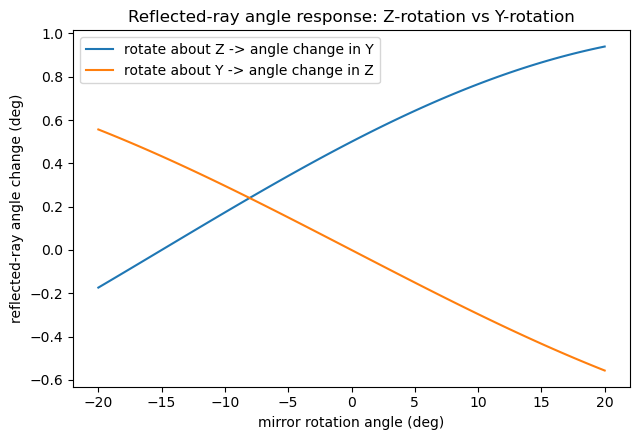

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(angles_deg, y_angle_deg, label="rotate about Z -> angle change in Y")
ax.plot(angles_deg, z_angle_deg, label="rotate about Y -> angle change in Z")
# ax.plot(angles_deg, 2 * angles_deg, "--", color="gray", label="2x mirror rotation (ideal)")
ax.set_xlabel("mirror rotation angle (deg)")
ax.set_ylabel("reflected-ray angle change (deg)")
ax.set_title("Reflected-ray angle response: Z-rotation vs Y-rotation")
ax.legend()
fig.tight_layout()
plt.show()

In [9]:
z_angle_deg[-1] - z_angle_deg[0]

np.float64(-1.113340798452839)

**Reading the plot (raw transverse component):**

Plotting the raw transverse direction cosine (`w[1]` for the Z-rotation, `w[2]`
for the Y-rotation) already hints at the real story: the Z-rotation curve
swings over a larger range than the Y-rotation curve. That gap is the
`cos(theta_i)` factor - the Y-rotation's out-of-plane component is
`w_z = cos(theta_i)*sin(2a)`, so its amplitude is scaled down by
`cos(theta_i) = cos 30 deg ≈ 0.87` relative to the in-plane response.

The *angular law* is still the same `2a` for both (that factor cancels in an
`arctan2` angle); the difference lives entirely in the amplitude. And amplitude
is exactly what a beam profiler sees - the spot lands at (transverse angle) x
(distance). So the physically-honest thing to plot is the beam-spot position on
the profiler, done in the next section, where the `cos(theta_i)` suppression of
the out-of-plane axis is the real, measurable difference between the two mirror
axes.

### 3D picture

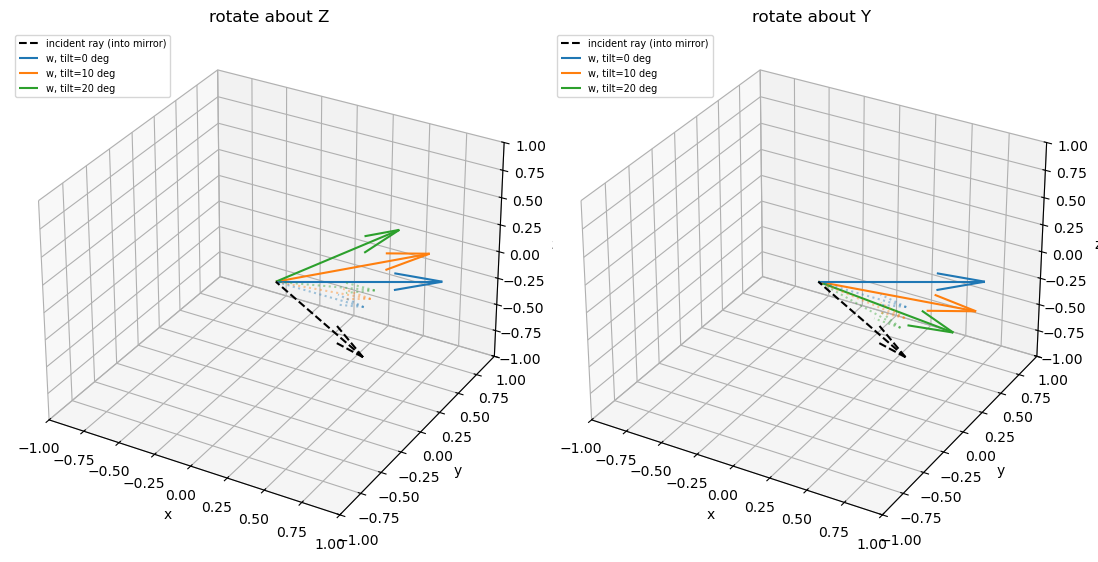

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

fig = plt.figure(figsize=(11, 5.5))
sample_angles_deg = [0, 10, 20]
colors = ["C0", "C1", "C2"]

for panel, (Rfun, label) in enumerate([(Rz, "rotate about Z"), (Ry, "rotate about Y")]):
    ax = fig.add_subplot(1, 2, panel + 1, projection="3d")
    origin = np.zeros(3)
    ax.quiver(*origin, *(-u), color="k", linestyle="--", length=1.0, label="incident ray (into mirror)")
    for a_deg, c in zip(sample_angles_deg, colors):
        a = np.deg2rad(a_deg)
        v = Rfun(a) @ v0
        w = reflection_matrix(v) @ u
        ax.quiver(*origin, *v, color=c, alpha=0.4, length=0.6, linestyle=":")
        ax.quiver(*origin, *w, color=c, length=1.0, label=f"w, tilt={a_deg} deg")
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(label)
    ax.legend(fontsize=7, loc="upper left")

fig.tight_layout()
plt.show()

## Beam-spot on a beam-perpendicular profiler, by the parameterization method

A real beam profiler faces the beam, so model the screen as the plane
**perpendicular to the un-tilted reflected beam `w0`**, a distance `L` away:

```
w0_hat · r = L
```

At `theta_i = 45°`, `w0` points along `(1, 1, 0)`, so this plane is literally
`x + y = k`. In general its normal is `w0 = (cos θ, sin θ, 0)`.

Same parameterization method as before - reflect with the matrix to get `w`,
write the ray `r(t) = t·w`, solve `w0_hat·(t·w) = L` for `t`, land at `P = t·w`
- but now we **project `P` onto the screen's own axes** to read the profiler
coordinates:

- `e_h` - horizontal in-screen axis (in-plane), swept by the **Z-rotation**;
- `e_v = z` - vertical in-screen axis (out-of-plane), swept by the **Y-rotation**.

This fixes the blow-up. On the old `x = L` plane the spot went to infinity as
the beam turned parallel to the screen (`tan(θ + 2a) → ∞`). A beam-facing screen
never grazes the beam, so both curves stay finite and nearly linear:

```
horizontal (X-piezo, Z-rot): spot_h = -L·tan(2a)      ≈ -2L·a
vertical   (Y-piezo, Y-rot): spot_v ≈ -2L·cos(theta_i)·a
ratio = sec(theta_i)     (X-piezo larger)
```

This `sec θ` ratio is the honest, screen-independent one - it comes purely from
the real angular effect (the out-of-plane rotation steers the beam only
`2a·cos θ`). The extra `sec θ` that made the `x = L` plane read `sec²θ` was an
artifact of that oblique screen.

In [ ]:
# --- Beam-spot on a profiler PERPENDICULAR to the beam, by the parameterization method ---
# Same reflection-matrix machinery to get the reflected direction w, then write the
# ray r(t) = t*w and solve for where it pierces the screen. Now the screen is the
# plane perpendicular to the un-tilted beam w0 (a real profiler faces the beam):
#
#     w0_hat . r = L        <- plane normal is the beam direction, distance L
#
# At theta_i = 45deg, w0 points along (1, 1, 0), so this plane is literally x + y = k.
# In general its normal is w0 = (cos theta_i, sin theta_i, 0).
L = 0.42  # mirror -> profiler distance along the beam (m)

w0_hat = w0 / np.linalg.norm(w0)
e_v = np.array([0.0, 0.0, 1.0])          # vertical in-screen axis (out-of-plane); already _|_ w0
e_h = np.cross(w0_hat, e_v)              # horizontal in-screen axis (in-plane)
e_h /= np.linalg.norm(e_h)


def screen_hit(w):
    """Intersect ray r(t)=t*w with the plane w0_hat.r = L, then PROJECT the landing
    point onto the screen's own axes -> (horizontal, vertical) position on the profiler."""
    w = w / np.linalg.norm(w)
    t = L / (w0_hat @ w)                 # solve w0_hat . (t*w) = L
    P = t * w                            # 3D landing point on the plane
    return np.array([P @ e_h, P @ e_v])  # project onto the in-plane / vertical screen axes


# Z-rotation (X-piezo) drives the horizontal spot; Y-rotation (Y-piezo) the vertical.
spot_h = np.array([screen_hit(reflection_matrix(Rz(a) @ v0) @ u)[0] for a in angles])
spot_v = np.array([screen_hit(reflection_matrix(Ry(a) @ v0) @ u)[1] for a in angles])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(angles_deg, 1e3 * spot_h, label="Z-rotation (X-piezo) -> horizontal on profiler")
ax.plot(angles_deg, 1e3 * spot_v, label="Y-rotation (Y-piezo) -> vertical on profiler")
ax.set_xlabel("mirror rotation angle (deg)")
ax.set_ylabel("spot position on profiler (mm)")
ax.set_title(f"Beam-perpendicular profiler, L={L} m, theta_i={np.rad2deg(theta_i):.0f} deg")
ax.legend()
fig.tight_layout()
plt.show()

# small-signal slopes at a=0 (central difference) vs the closed forms
da = 1e-4
sH = (screen_hit(reflection_matrix(Rz(da) @ v0) @ u)[0]
      - screen_hit(reflection_matrix(Rz(-da) @ v0) @ u)[0]) / (2 * da)
sV = (screen_hit(reflection_matrix(Ry(da) @ v0) @ u)[1]
      - screen_hit(reflection_matrix(Ry(-da) @ v0) @ u)[1]) / (2 * da)
print(f"horizontal slope (X-piezo, Z-rot) = {sH:+.4f} m/rad   closed form  -2L            = {-2*L:+.4f}")
print(f"vertical   slope (Y-piezo, Y-rot) = {sV:+.4f} m/rad   closed form  -2L*cos(theta) = {-2*L*np.cos(theta_i):+.4f}")
print(f"ratio |H/V| = {abs(sH/sV):.4f}   = sec(theta_i) = {1/np.cos(theta_i):.4f}   (X-piezo larger)")
print("\nNo divergence over the sweep: the beam never grazes this screen (it faces the beam),")
print("unlike the x=L plane where tan(theta_i+2a) blew up as the beam turned parallel to it.")

In [ ]:
# --- Can this geometry alone explain the X/Y sensitivity gap in the scans? ---
# For a SINGLE mirror both tilt axes see the SAME incidence angle theta_i, so the
# X-piezo/Y-piezo sensitivity ratio is a pure function of theta_i:
#   sec(theta_i)    if the profiler is perpendicular to the beam
#   sec^2(theta_i)  if the profiler is the x=L plane (as parameterized above)
# Plot both to read off how oblique the hit must be to fake a given ratio.
th = np.deg2rad(np.linspace(0, 75, 300))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(np.rad2deg(th), 1 / np.cos(th), label="sec(θ)  (screen ⟂ beam)")
ax.plot(np.rad2deg(th), 1 / np.cos(th) ** 2, label="sec²(θ)  (screen x=L)")
ax.axhline(2.0, color="C3", ls=":", lw=1)
ax.text(1, 2.05, "2x gap", color="C3", fontsize=8)
ax.axvline(np.rad2deg(theta_i), color="gray", ls="--", lw=1)
ax.text(np.rad2deg(theta_i) + 0.5, 1.05, f"theta_i={np.rad2deg(theta_i):.0f}°", color="gray", fontsize=8)
ax.set_xlabel("incidence angle theta_i (deg)")
ax.set_ylabel("X-piezo / Y-piezo sensitivity ratio")
ax.set_title("Geometric sensitivity ratio (X-piezo always larger)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Takeaways for the experiment:**

- **The X-piezo (in-plane, Z-rotation) is genuinely the more sensitive axis** on
  a beam-facing profiler, which is the direction you see in the scans. It comes
  from a real angular effect: rotating the mirror by `a` about an in-surface axis
  rotates the beam by `2a` about that axis, giving a deflection `2a·sin γ`, where
  `γ` is the angle between the beam and the rotation axis. The Z axis is
  perpendicular to the beam (`sin γ = 1` → full `2a`); the Y axis is not
  (`sin γ = cos θ` → only `2a·cos θ`). So the ratio is `sec θ`, X-piezo larger.
- **Magnitude:** `sec θ` = 1.15 at 30°, 1.41 at 45°, 2.0 only at 60°. So on a
  beam-perpendicular profiler, geometry gives at most ~1.4x at a 45° hit - it
  biases X larger but can't by itself make a full ~2x gap unless the incidence
  angle is quite oblique (~60°). The remainder is controller/actuator asymmetry
  (consistent with the piezo-mirrors findings). Worth measuring the actual
  incidence angle on the bench to see how much is geometry.
- **Screen choice matters, so be careful with `analysis.ipynb`.** The oblique
  `x = L` plane inflated the ratio to `sec²θ`; a beam-facing profiler gives
  `sec θ`. And `analysis.ipynb` back-converts displacement to "mirror angle" via
  `disp / (2L)` assuming the ideal `2L` - the out-of-plane axis actually lands at
  `2L·cos θ`, so that axis is under-reported by `cos θ` even if its true
  mechanical tilt-per-volt matched the in-plane axis.